# Gaussian Mixture Models — LibriSpeech Acoustic Analysis

## Task 0 — Download LibriSpeech dev-clean

In [12]:
import os
import requests

DATA_DIR = "../data/audio"
os.makedirs(DATA_DIR, exist_ok=True)

URL = "https://www.openslr.org/resources/12/dev-clean.tar.gz"
TAR_PATH = os.path.join(DATA_DIR, "librispeech_dev_clean.tar.gz")

print("Downloading LibriSpeech dev-clean...")
r = requests.get(URL, stream=True, timeout=120)
r.raise_for_status()

total = 0
with open(TAR_PATH, "wb") as f:
    for chunk in r.iter_content(chunk_size=1024 * 1024):
        if chunk:
            f.write(chunk)
            total += len(chunk)
            print(f"Downloaded {total / 1024 / 1024:.1f} MB", end="\r")

print("\nDownload complete.")

Downloaded 322.3 MB
Download complete.


In [13]:
import tarfile

EXTRACT_DIR = os.path.join(DATA_DIR, "LibriSpeech", "dev-clean")

if not os.path.isdir(EXTRACT_DIR):
    print("Extracting archive...")
    with tarfile.open(TAR_PATH, "r:gz") as tar:
        tar.extractall(path=DATA_DIR)
    print("Extraction complete.")
else:
    print("Already extracted.")

Already extracted.


## Task 1 — Collect Audio Files

In [14]:
import random
import soundfile as sf

audio_files = []
for root, _, files in os.walk(EXTRACT_DIR):
    for f in files:
        if f.lower().endswith(".flac"):
            audio_files.append(os.path.join(root, f))

print("Number of audio files:", len(audio_files))

if len(audio_files) == 0:
    raise RuntimeError("No audio files found. Check EXTRACT_DIR and file extension.")

sample_path = random.choice(audio_files)
x, sr = sf.read(sample_path)

print("Sample file:", sample_path)
print("Sample rate:", sr)
print("Duration (seconds):", len(x) / sr)

Number of audio files: 2703
Sample file: ../data/audio/LibriSpeech/dev-clean/6345/64257/6345-64257-0013.flac
Sample rate: 16000
Duration (seconds): 6.295


## Task 2 — Play Audio and Plot Waveform

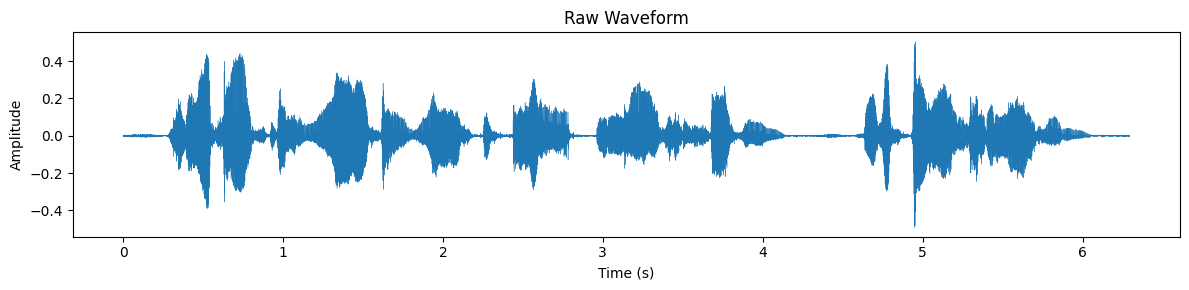

In [15]:
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np

ipd.display(ipd.Audio(x, rate=sr))

t = np.arange(len(x)) / sr
plt.figure(figsize=(12, 3))
plt.plot(t, x, linewidth=0.3)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Raw Waveform")
plt.tight_layout()
plt.show()

**Interpretation:** Single speaker, clean recording, no background noise. The waveform shows alternating speech bursts and silent pauses reflecting natural speech rhythm.

## Task 3 — GMM Modeling Assumptions for Audio

An observation is a short-time frame feature vector (~25 ms), not a raw sample or full utterance. Raw waveforms are unsuitable because samples are correlated and lack spectral meaning. MFCCs compress the spectral envelope into a low-dimensional, decorrelated representation where each Gaussian component corresponds to an acoustic-phonetic class (e.g., vowel, fricative, silence).

## Task 4 — Waveform, Spectrogram, and MFCC Visualization

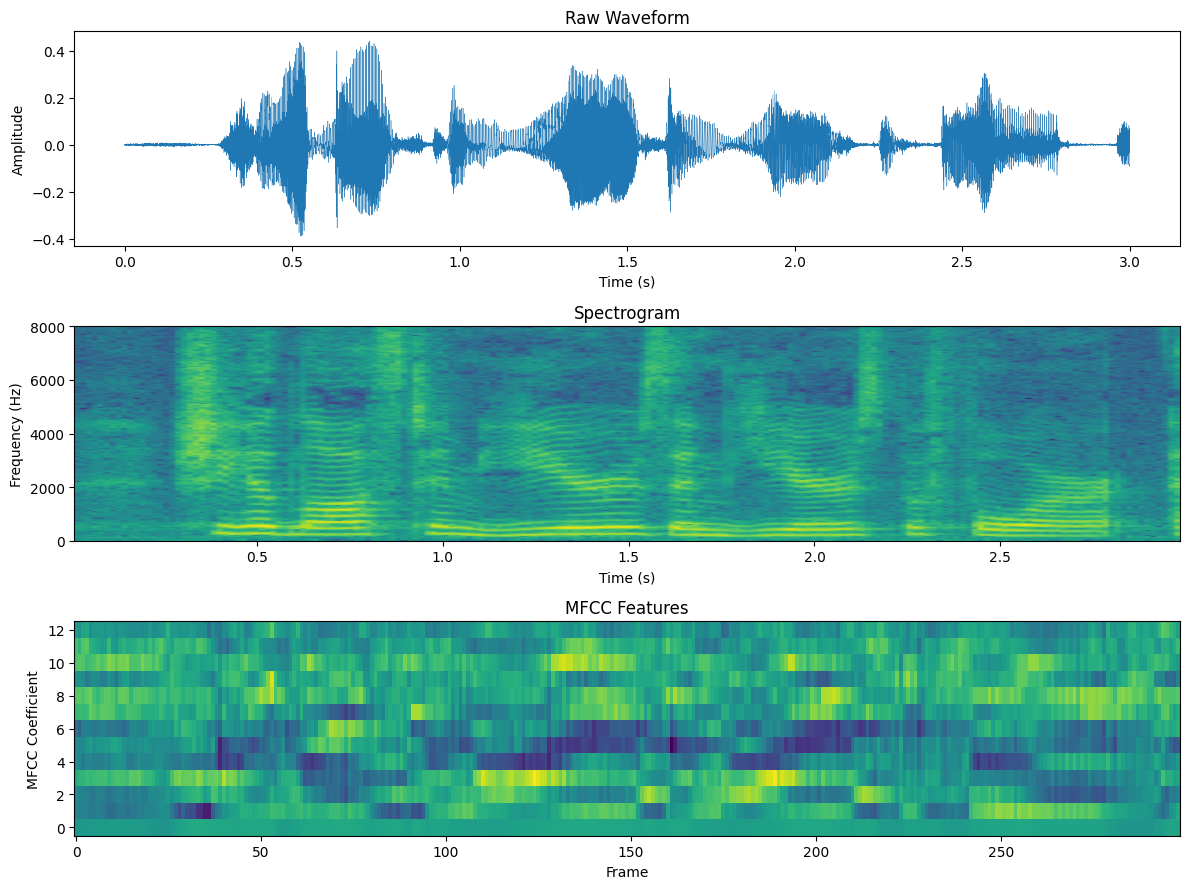

Waveform shape: (48000,)
Spectrogram: computed via short-time FFT (512-point windows)
MFCC shape: (299, 13)


In [16]:
from python_speech_features import mfcc
from scipy.io import wavfile

seg = x[:int(3 * sr)]

fig, axes = plt.subplots(3, 1, figsize=(12, 9))

t_seg = np.arange(len(seg)) / sr
axes[0].plot(t_seg, seg, linewidth=0.3)
axes[0].set_title("Raw Waveform")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

axes[1].specgram(seg, Fs=sr, NFFT=512, noverlap=256, cmap="viridis")
axes[1].set_title("Spectrogram")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (Hz)")

mfcc_feat = mfcc(seg, samplerate=sr, numcep=13, nfilt=26, winlen=0.025, winstep=0.01)
axes[2].imshow(mfcc_feat.T, aspect="auto", origin="lower", cmap="viridis")
axes[2].set_title("MFCC Features")
axes[2].set_xlabel("Frame")
axes[2].set_ylabel("MFCC Coefficient")

plt.tight_layout()
plt.show()

print("Waveform shape:", seg.shape)
print("Spectrogram: computed via short-time FFT (512-point windows)")
print("MFCC shape:", mfcc_feat.shape)

**Interpretation:** The waveform is raw amplitude over time; the spectrogram reveals time–frequency energy but is high-dimensional; MFCCs compress the spectral envelope into 13 compact, decorrelated coefficients per frame — a much better fit for GMM's Gaussian assumption.

## Task 5 — Extract MFCC Feature Matrix

In [17]:
random.seed(42)
subset = random.sample(audio_files, min(100, len(audio_files)))

all_mfcc = []
for path in subset:
    sig, rate = sf.read(path)
    feats = mfcc(sig, samplerate=rate, numcep=13, nfilt=26, winlen=0.025, winstep=0.01)
    all_mfcc.append(feats)

X = np.vstack(all_mfcc)
n, d = X.shape
print(f"X shape: n={n} frames, d={d} dimensions")

X shape: n=76606 frames, d=13 dimensions


**Interpretation:** Each row of X is a 13-D MFCC vector for one ~25 ms frame. The GMM treats each row as an i.i.d. observation and clusters them into K acoustic-phonetic categories.

## Task 6 — Standardize Features

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Post-standardization statistics (first 5 dimensions):")
for i in range(5):
    print(f"  Dim {i}: mean={X_scaled[:, i].mean():.6f}, std={X_scaled[:, i].std():.6f}")

Post-standardization statistics (first 5 dimensions):
  Dim 0: mean=-0.000000, std=1.000000
  Dim 1: mean=0.000000, std=1.000000
  Dim 2: mean=0.000000, std=1.000000
  Dim 3: mean=0.000000, std=1.000000
  Dim 4: mean=-0.000000, std=1.000000


**Interpretation:** MFCC dimensions have very different scales. Without standardization, high-variance dimensions dominate the likelihood and EM converges poorly. Scaling to zero mean / unit variance ensures all features contribute equally.

## Task 7 — Fit GMMs and Compare BIC

In [19]:
from sklearn.mixture import GaussianMixture

Ks = [2, 4, 8, 15]
results = []

for k in Ks:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42, max_iter=200)
    gmm.fit(X_scaled)
    avg_ll = gmm.score(X_scaled)
    bic = gmm.bic(X_scaled)
    results.append((k, avg_ll, bic))
    print(f"K={k:2d}  |  Avg Log-Likelihood={avg_ll:.4f}  |  BIC={bic:.1f}")

best_k = min(results, key=lambda r: r[2])[0]
print(f"\nBest K by BIC: {best_k}")

K= 2  |  Avg Log-Likelihood=-16.8565  |  BIC=2584969.4
K= 4  |  Avg Log-Likelihood=-16.3313  |  BIC=2506864.8
K= 8  |  Avg Log-Likelihood=-16.0188  |  BIC=2463704.9
K=15  |  Avg Log-Likelihood=-15.6537  |  BIC=2416031.0

Best K by BIC: 15


**Interpretation:** Log-likelihood improves and BIC decreases monotonically as K grows, selecting K=15. The data contains at least 15 distinct spectral patterns, and the complexity penalty does not yet outweigh the fit improvement.

## Task 8 — Refit Best Model and Report Weights

In [20]:
best_gmm = GaussianMixture(n_components=best_k, covariance_type="full", random_state=42, max_iter=200)
best_gmm.fit(X_scaled)

print(f"Selected K = {best_k}")
print("Mixture weights:")
for i, w in enumerate(best_gmm.weights_):
    print(f"  Component {i}: {w:.4f}")

Selected K = 15
Mixture weights:
  Component 0: 0.0803
  Component 1: 0.0269
  Component 2: 0.0400
  Component 3: 0.0818
  Component 4: 0.0306
  Component 5: 0.1159
  Component 6: 0.0612
  Component 7: 0.0449
  Component 8: 0.0836
  Component 9: 0.0417
  Component 10: 0.1340
  Component 11: 0.1020
  Component 12: 0.0536
  Component 13: 0.0717
  Component 14: 0.0317


**Interpretation:** Weights range ~0.03–0.13. High-weight components capture frequent sounds (common vowels, silence); low-weight ones capture rarer patterns (fricatives). Weights reflect phonetic class frequency, not distinct speakers.

## Task 9 — Posterior Responsibility Histogram

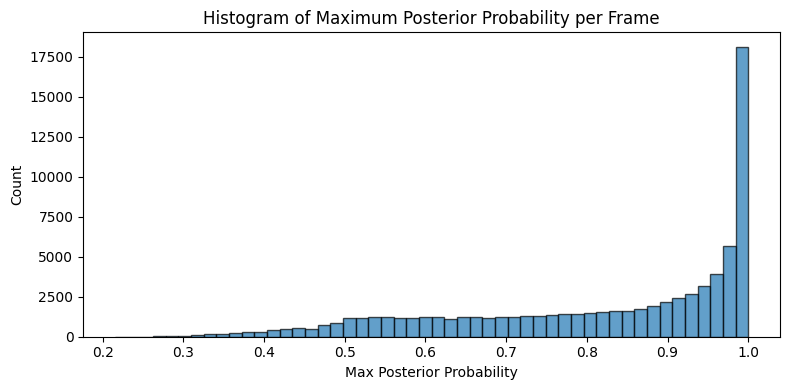

In [21]:
responsibilities = best_gmm.predict_proba(X_scaled)
max_prob = responsibilities.max(axis=1)

plt.figure(figsize=(8, 4))
plt.hist(max_prob, bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Max Posterior Probability")
plt.ylabel("Count")
plt.title("Histogram of Maximum Posterior Probability per Frame")
plt.tight_layout()
plt.show()

**Interpretation:** The histogram is right-skewed with a spike near 1.0 — many frames are confidently assigned to one component. Frames with lower max probability (~0.4–0.8) are transitional or ambiguous regions where components overlap in MFCC space.

## Task 10 — 2D Marginal Visualization of the GMM

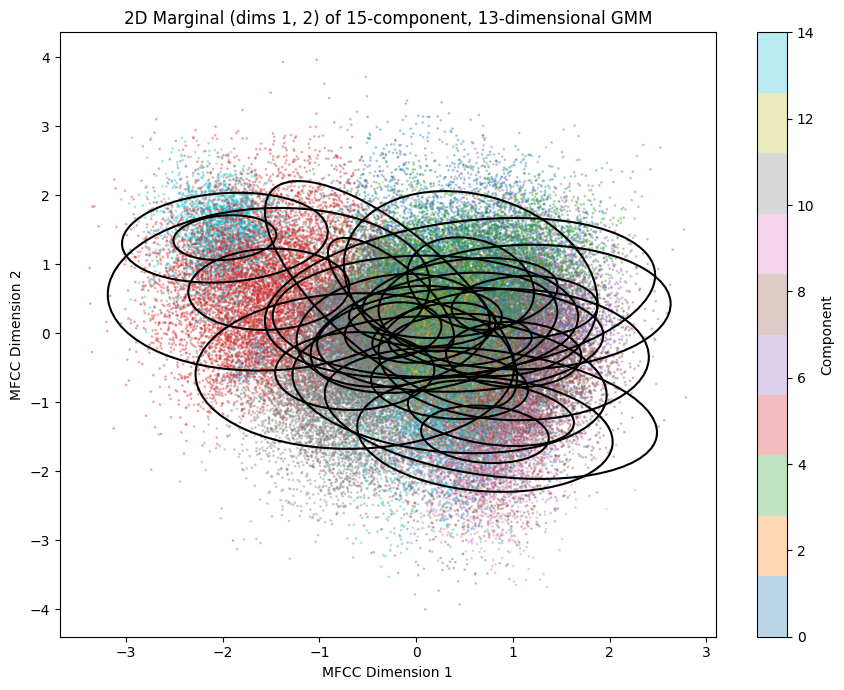

In [22]:
from matplotlib.patches import Ellipse

dim1, dim2 = 1, 2
labels = best_gmm.predict(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(X_scaled[:, dim1], X_scaled[:, dim2], c=labels, cmap="tab10", s=1, alpha=0.3)

for k in range(best_k):
    mean = best_gmm.means_[k, [dim1, dim2]]
    cov = best_gmm.covariances_[k][np.ix_([dim1, dim2], [dim1, dim2])]
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
    for n_std in [1, 2]:
        w, h = 2 * n_std * np.sqrt(vals)
        ell = Ellipse(xy=mean, width=w, height=h, angle=angle,
                      edgecolor="black", facecolor="none", linewidth=1.5)
        ax.add_patch(ell)

ax.set_xlabel(f"MFCC Dimension {dim1}")
ax.set_ylabel(f"MFCC Dimension {dim2}")
ax.set_title(f"2D Marginal (dims {dim1}, {dim2}) of {best_gmm.n_components}-component, {d}-dimensional GMM")
plt.colorbar(scatter, label="Component")
plt.tight_layout()
plt.show()

## Task 11 — Limitations of Frame-Level GMMs

A frame-level GMM treats each frame as independent, ignoring temporal order. It cannot model phoneme transitions or speaker persistence, so it does not solve diarization. Extensions like **HMMs** (Markov chain over latent states with GMM emissions) or **speaker embeddings** (x-vectors + clustering) are needed to capture dynamics and speaker continuity.